In [3]:
#!pip install kmodes

# Análisis de datos y computación numérica
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning y Preprocesamiento
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from kmodes.kprototypes import KPrototypes

# Visualización Geográfica
import folium
from folium.plugins import MarkerCluster
from branca.colormap import LinearColormap

In [4]:
#Carpeta de ficheros_csv del drive
!gdown --folder -q https://drive.google.com/drive/folders/1GcfvHOr_N3NyKCmp6w1dX6HJ2JRfO1mD?usp=drive_link

In [5]:
# Carga de datos
df_limpios = pd.read_csv("/content/Ficheros CSV/datos_Idealista_limpios.csv")

/tmp/ipython-input-3388472322.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_limpios = pd.read_csv("/content/Ficheros CSV/datos_Idealista_limpios.csv")


In [6]:
df_limpios.shape

(17456, 33)

## Opcion 1, Clustering geográfico

#### 1. Feature Engineering
Se crean nuevas variables para enriquecer el análisis. Estas incluyen la distancia al centro para el contexto geográfico, ratios de precio y tamaño por habitación para normalizar el valor, y una puntuación de comodidades para medir la calidad del inmueble.

In [7]:
# 1. Features Geográficas

# Coordenadas referencia (Puerta del Sol)
lat_centro, lon_centro = 40.416775, -3.703790

# Distancia euclidiana
df_limpios['distancia_al_centro'] = np.sqrt(
    (df_limpios['latitude'] - lat_centro)**2 + (df_limpios['longitude'] - lon_centro)**2
) * 111.32

# 2. Features de Valor y Calidad

# Ratios para normalizar por habitación
df_limpios['price_per_room'] = df_limpios['price'] / df_limpios['rooms'].replace(0, 1)
df_limpios['size_per_room'] = df_limpios['size'] / df_limpios['rooms'].replace(0, 1)

# Puntuación sumando comodidades (columnas binarias 0/1)
amenities_cols = [
    'exterior', 'hasLift', 'parkingSpace.hasParkingSpace', 'newDevelopment',
    'has360', 'has3DTour', 'hasPlan', 'hasStaging', 'hasVideo'
]
df_limpios['amenities_score'] = df_limpios[amenities_cols].sum(axis=1)

#### 2. Clustering Geográfico para Definir Zonas
Se utiliza el algoritmo KMeans para agrupar los inmuebles en zonas geográficas basándose en su ubicación y cercanía al centro.

El primer paso es un análisis para determinar el número óptimo de clusters (k), utilizando el método del codo (inercia) y la puntuación de silueta. Esto asegura que la segmentación de zonas sea estadísticamente coherente antes de aplicar el modelo final.

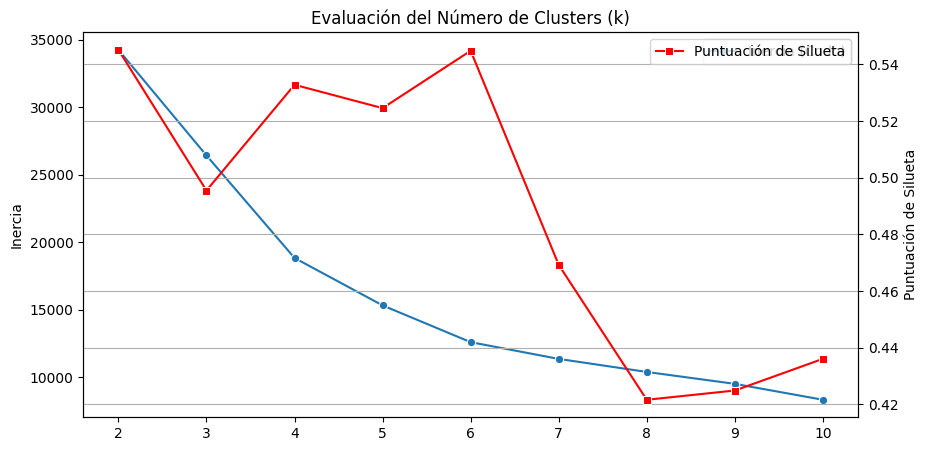

In [8]:
# Seleccionar y escalar variables para el clustering geográfico
geo_features = ['latitude', 'longitude', 'distancia_al_centro']
X_geo = df_limpios[geo_features]
scaler = StandardScaler()
X_geo_scaled = scaler.fit_transform(X_geo)

# Encontrar el número óptimo de clusters (k)
k_range = range(2, 11)
inertia_values = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_geo_scaled)
    inertia_values.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_geo_scaled, kmeans.labels_))

# Visualizar los resultados para decidir k
plt.figure(figsize=(10, 5))
sns.lineplot(x=k_range, y=inertia_values, marker='o', label='Inercia (Codo)')
plt.ylabel('Inercia')
plt.twinx()
sns.lineplot(x=k_range, y=silhouette_scores, marker='s', color='r', label='Puntuación de Silueta')
plt.ylabel('Puntuación de Silueta')
plt.title('Evaluación del Número de Clusters (k)')
plt.grid(True)
plt.show()



#### 3. Generación de deal_scores para Múltiples k
Se realiza un análisis comparativo para determinar el nivel de granularidad óptimo en la zonificación. Para ello, se ejecuta el algoritmo KMeans de forma iterativa para un rango extendido de valores de k (6, 15, 30, 50, 200).

Aunque el método del codo sugirió k=6 como el punto de mayor eficiencia estadística, se decidió probar con valores de k más altos por una razón de negocio fundamental. Un número bajo de clusters tiende a crear "macro-zonas" muy amplias que, si bien son estadísticamente distintas entre sí, pueden ser muy heterogéneas internamente, mezclando barrios con realidades de mercado muy diferentes.

In [9]:
# Generación de clusters y deal_scores con k=6, 15, 30, 50 y 200 ---

k_values = [6, 15, 30, 50, 200]

# Entrenar el modelo KMeans para cada k
for k in k_values:

    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    df_limpios[f'zona_cluster_k{k}'] = kmeans.fit_predict(X_geo_scaled)

    # Calcular la mediana del precio para cada nuevo conjunto de clusters
    median_price_col = f'median_price_k{k}'
    df_limpios[median_price_col] = df_limpios.groupby(f'zona_cluster_k{k}')['priceByArea'].transform('median')

    # Calcular el deal_score para cada k
    deal_score_col = f'deal_score_k{k}'
    df_limpios[deal_score_col] = (df_limpios['priceByArea'] - df_limpios[median_price_col]) / df_limpios[median_price_col]

cols_to_show = [f'deal_score_k{k}' for k in k_values]
print("Muestra de los 'deal_scores' generados:")
print(df_limpios[cols_to_show].head())

Muestra de los 'deal_scores' generados:
   deal_score_k6  deal_score_k15  deal_score_k30  deal_score_k50  \
0       0.357082        0.102571       -0.098685        0.169121   
1      -0.081232       -0.253540       -0.389794       -0.208485   
2       0.357082        0.102571       -0.098685        0.169121   
3       0.274327        0.035336        0.552577        0.588608   
4       1.025385        1.900982        1.434004        2.137090   

   deal_score_k200  
0         0.269432  
1        -0.287439  
2         0.269432  
3         0.285531  
4         0.808128  


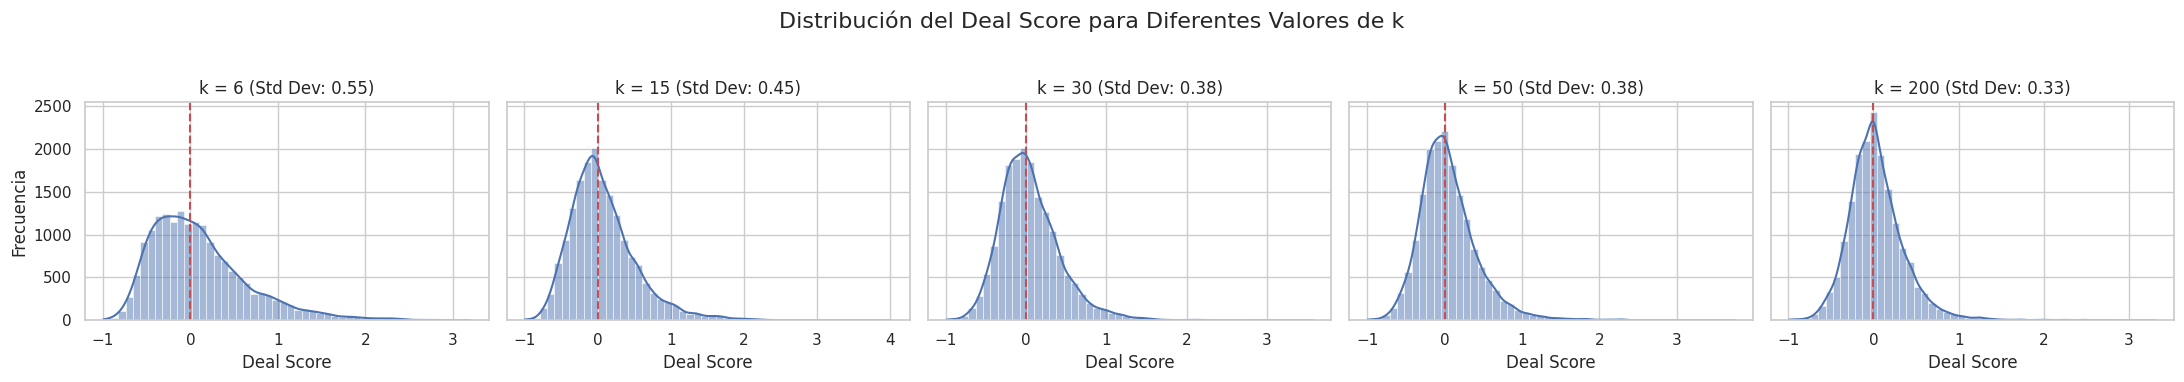


Descripción estadística de cada Deal Score:
       deal_score_k6  deal_score_k15  deal_score_k30  deal_score_k50  \
count   17456.000000    17456.000000    17456.000000    17456.000000   
mean        0.098646        0.075273        0.047875        0.051985   
std         0.553788        0.452875        0.376034        0.380879   
min        -0.992433       -0.992751       -0.992784       -0.993243   
25%        -0.305635       -0.231845       -0.205495       -0.193379   
50%         0.000000        0.000000        0.000000        0.000000   
75%         0.374531        0.300471        0.250984        0.236656   
max         3.199850        4.020833        3.570641        3.741637   

       deal_score_k200  
count     17456.000000  
mean          0.034898  
std           0.331555  
min          -0.991621  
25%          -0.173462  
50%           0.000000  
75%           0.197974  
max           3.312650  


In [10]:

#Comparación visual de las distribuciones de deal_score

sns.set(style="whitegrid")

fig, axes = plt.subplots(1, 5, figsize=(22, 4), sharey=True)
fig.suptitle('Distribución del Deal Score para Diferentes Valores de k', fontsize=16)

# Lista de k y las columnas correspondientes
deal_score_cols = [f'deal_score_k{k}' for k in k_values]

for i, col in enumerate(deal_score_cols):
    # Crear histograma
    sns.histplot(ax=axes[i], data=df_limpios, x=col, kde=True, bins=50)
    axes[i].axvline(0, color='r', linestyle='--')

    # Calcular desviación estándar
    std_dev = df_limpios[col].std()
    axes[i].set_title(f'k = {k_values[i]} (Std Dev: {std_dev:.2f})')
    axes[i].set_xlabel('Deal Score')

axes[0].set_ylabel('Frecuencia')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Show
print("\nDescripción estadística de cada Deal Score:")
print(df_limpios[deal_score_cols].describe())

### Selección para el Clustering
Tras analizar el rendimiento para diferentes valores de k, se ha seleccionado **k=50** como el número óptimo de clusters.

Esta decisión representa un equilibrio entre granularidad y robustez. Mientras que k=6 (sugerido por el método del codo) crea zonas demasiado amplias que ocultan variaciones de precios locales, k=200 (con las mejores métricas estadísticas) introduce un riesgo elevado de sobreajuste y de crear clusters con pocos inmuebles, cuya mediana de precio sería estadísticamente inestable.

El valor k=50 captura la mayor parte de la mejora en la precisión del deal_score sin añadir una complejidad excesiva. Posteriormente, este enfoque de zonificación por datos se comparará con un modelo que utilice límites administrativos (ej. municipios, con ~178 categorías) para determinar qué estrategia es más predictiva.

### Visualizacion del clustering

In [11]:
def visualizar_clusters_en_mapa(df, k):
    """
    Genera un mapa de Folium visualizando los clusters para un valor k específico.

    Args:
        df (pd.DataFrame):
        k (int): El número de clusters.
    """
    # Construye el nombre de la columna dinámicamente a partir de k
    cluster_col = f'zona_cluster_k{k}'

    # Mapa base centrado en Madrid
    mapa = folium.Map(location=[df['latitude'].mean(), df['longitude'].mean()], zoom_start=11)

    # Paleta de colores
    num_clusters = df[cluster_col].nunique()
    colors = sns.color_palette('bright', n_colors=num_clusters).as_hex()

    # 3. Añadir puntos al mapa
    sample_size = df.shape[0]
    df_sample = df.sample(n=sample_size, random_state=42)

    for index, row in df_sample.iterrows():
        cluster_id = row[cluster_col]

        folium.CircleMarker(
            location=[row['latitude'], row['longitude']],
            radius=3,
            color=colors[cluster_id],
            fill=True,
            fill_color=colors[cluster_id],
            fill_opacity=0.6,
            popup=f"Zona k={k}: {cluster_id}<br>Precio: {row['price']:,.0f} €"
        ).add_to(mapa)

    # return
    return mapa

mapa_k50 = visualizar_clusters_en_mapa(df_limpios, 50) #Cambia el valor a uno de los calculados antes por si quieres comparar
mapa_k50

Output hidden; open in https://colab.research.google.com to view.

### 4. Creación de la Variable Objetivo (deal_score con k=50)
Utilizando la zonificación óptima seleccionada (k=50), este bloque calcula la variable objetivo final.

El proceso consiste en dos pasos:

- Se calcula el precio mediano por metro cuadrado para cada una de las 50 zonas, estableciendo así un "precio de mercado" de referencia para cada área.

- Se genera la columna deal_score_k50, que mide la desviación porcentual de cada inmueble respecto a la mediana de su zona.

Un valor negativo en esta columna indica una buena oferta, mientras que uno positivo sugiere un sobreprecio. Esta variable será fundamental para el entrenamiento del modelo final.

In [12]:
# Precio mediano por metro cuadrado para cada una de las 50 zonas
df_limpios['median_price_k50'] = df_limpios.groupby('zona_cluster_k50')['priceByArea'].transform('median')

# Calcular el 'deal_score' basado en los clusters de k=50
df_limpios['deal_score_k50'] = (df_limpios['priceByArea'] - df_limpios['median_price_k50']) / df_limpios['median_price_k50']

# Resultado
print("Verificación de las nuevas columnas (k=50):")
cols_to_show = ['zona_cluster_k50', 'priceByArea', 'median_price_k50', 'deal_score_k50']
print(df_limpios[cols_to_show].head())

print("\n--- Top 5 Mejores Ofertas (k=50) ---")
print(df_limpios.nsmallest(5, 'deal_score_k50')[cols_to_show])

print("\n--- Top 5 Peores Ofertas (k=50) ---")
print(df_limpios.nlargest(5, 'deal_score_k50')[cols_to_show])

Verificación de las nuevas columnas (k=50):
   zona_cluster_k50  priceByArea  median_price_k50  deal_score_k50
0                42       8019.0            6859.0        0.169121
1                42       5429.0            6859.0       -0.208485
2                42       8019.0            6859.0        0.169121
3                25       7530.0            4740.0        0.588608
4                46      11968.0            3815.0        2.137090

--- Top 5 Mejores Ofertas (k=50) ---
       zona_cluster_k50  priceByArea  median_price_k50  deal_score_k50
12383                 4         17.0            2516.0       -0.993243
14152                28         28.0            2388.0       -0.988275
6305                 40         37.0            2658.5       -0.986082
15511                 4         41.0            2516.0       -0.983704
15337                11         45.0            2277.0       -0.980237

--- Top 5 Peores Ofertas (k=50) ---
       zona_cluster_k50  priceByArea  median_price_k5

### Visualización del deal_score

/tmp/ipython-input-1076001591.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(


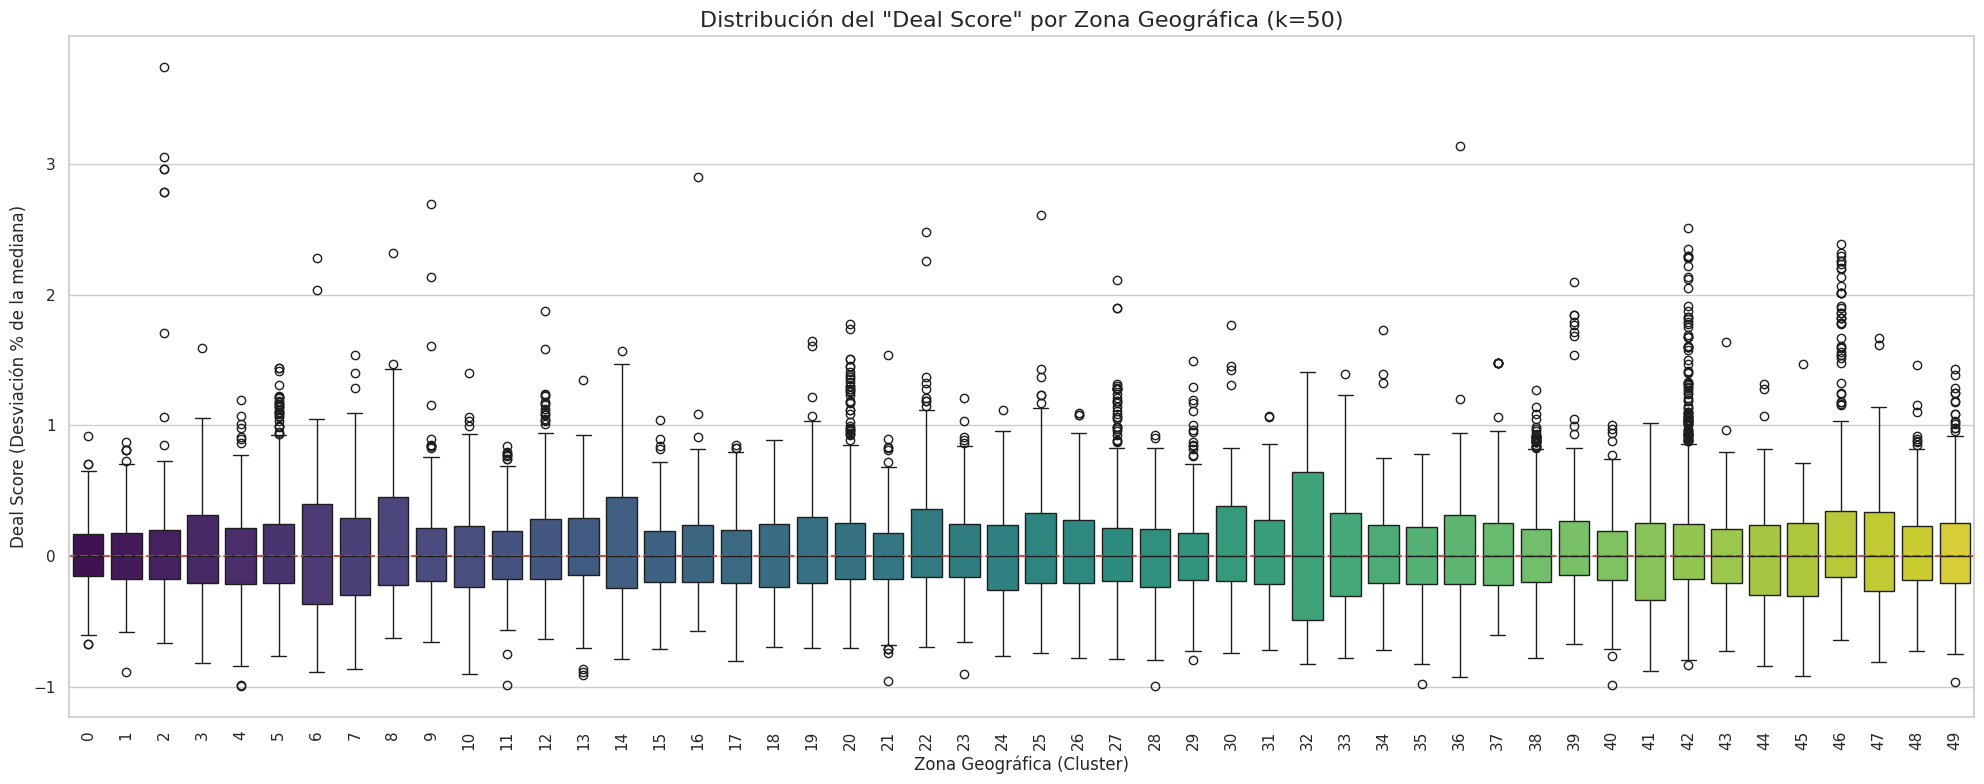

In [13]:
plt.figure(figsize=(20, 8))
sns.set(style="whitegrid")

# Crear boxplot
ax = sns.boxplot(
    x='zona_cluster_k50',
    y='deal_score_k50',
    data=df_limpios,
    palette='viridis'
)

ax.axhline(0, color='r', linestyle='--')

plt.title('Distribución del "Deal Score" por Zona Geográfica (k=50)', fontsize=16)
plt.xlabel('Zona Geográfica (Cluster)')
plt.ylabel('Deal Score (Desviación % de la mediana)')

# Rotar las etiquetas del eje X si son muchas y se solapan
if df_limpios['zona_cluster_k50'].nunique() > 25:
    plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

## Opcion 2, DBSCAN

Como alternativa a KMeans, se utiliza DBSCAN, un algoritmo de clustering basado en densidad. Sus principales ventajas para datos geográficos son:

- Puede encontrar clusters de formas irregulares, no solo esféricos.

- Aísla outliers de forma automática, marcándolos como "ruido" (cluster -1), lo cual es muy útil para identificar inmuebles geográficamente anómalos.

Antes de ejecutar el algoritmo, se realiza un análisis de k-distancia para estimar el parámetro eps (la distancia máxima para considerar a un punto como vecino) más adecuado para la estructura de nuestros datos.

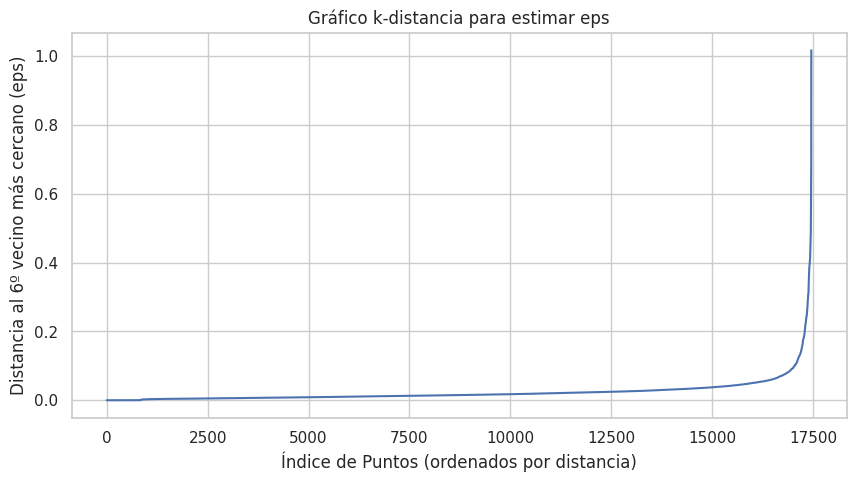

In [14]:
# Encontrar el parámetro 'eps' óptimo. (Usamos NearestNeighbors para calcular la distancia al k-ésimo vecino más cercano)
# Un buen punto de partida para 'min_samples' es 2 * número_de_features (en este caso, 2*3=6).

nn = NearestNeighbors(n_neighbors=6)
nbrs = nn.fit(X_geo_scaled) # Reutilizamos los datos geográficos escalados
distances, indices = nbrs.kneighbors(X_geo_scaled)

# Ordenamos y graficamos las distancias al 6º vecino (El punto de máxima curvatura ("codo") en este gráfico es un buen candidato para 'eps')
sorted_distances = np.sort(distances[:, 5]) # Distancias al 6º vecino (índice 5)

plt.figure(figsize=(10, 5))
plt.plot(sorted_distances)
plt.title("Gráfico k-distancia para estimar eps")
plt.xlabel("Índice de Puntos (ordenados por distancia)")
plt.ylabel("Distancia al 6º vecino más cercano (eps)")
plt.grid(True)
plt.show()

In [15]:
# Aplicar DBSCAN con los parámetros optimos (0.18)
optimal_eps = 0.18

dbscan = DBSCAN(eps=optimal_eps, min_samples=6)
df_limpios['zona_cluster_dbscan'] = dbscan.fit_predict(X_geo_scaled)


# Analizar los resultados del clustering (DBSCAN marca los outliers (ruido) con la etiqueta -1)
print("Distribución de inmuebles por cluster (DBSCAN):")
print(df_limpios['zona_cluster_dbscan'].value_counts())

# Calcular el 'deal_score' para los clusters de DBSCAN (Se calcula la mediana solo para los puntos que pertenecen a un cluster (se excluye el ruido))
median_prices_dbscan = df_limpios[df_limpios['zona_cluster_dbscan'] != -1].groupby('zona_cluster_dbscan')['priceByArea'].transform('median')

# Se crea la columna de mediana, que será NaN para los outliers (cluster -1)
df_limpios['median_price_dbscan'] = np.nan
df_limpios.loc[df_limpios['zona_cluster_dbscan'] != -1, 'median_price_dbscan'] = median_prices_dbscan

# El 'deal_score' será NaN para los outliers
df_limpios['deal_score_dbscan'] = (df_limpios['priceByArea'] - df_limpios['median_price_dbscan']) / df_limpios['median_price_dbscan']

# Verificación
print("\nMuestra del 'deal_score' para DBSCAN (excluyendo outliers):")
cols_to_show = ['zona_cluster_dbscan', 'priceByArea', 'median_price_dbscan', 'deal_score_dbscan']
print(df_limpios[df_limpios['zona_cluster_dbscan'] != -1][cols_to_show].head())

Distribución de inmuebles por cluster (DBSCAN):
zona_cluster_dbscan
0     12663
4       477
6       374
1       273
10      223
      ...  
90        6
69        6
80        6
84        6
91        6
Name: count, Length: 93, dtype: int64

Muestra del 'deal_score' para DBSCAN (excluyendo outliers):
   zona_cluster_dbscan  priceByArea  median_price_dbscan  deal_score_dbscan
0                    0       8019.0               5210.0           0.539155
1                    0       5429.0               5210.0           0.042035
2                    0       8019.0               5210.0           0.539155
3                    0       7530.0               5210.0           0.445298
4                    0      11968.0               5210.0           1.297121


In [16]:
#Visualización DBSCAN con Leyenda y Colores Corregidos ---

# Mapa base
mapa_dbscan_legend = folium.Map(location=[df_limpios['latitude'].mean(), df_limpios['longitude'].mean()], zoom_start=11)

# Paleta y mapa de colores
cluster_labels = df_limpios['zona_cluster_dbscan'].unique()
num_real_clusters = len([label for label in cluster_labels if label != -1])

colors = sns.color_palette('hsv', n_colors=num_real_clusters).as_hex()
color_map = {label: colors[i] for i, label in enumerate(sorted([l for l in cluster_labels if l != -1]))}
color_map[-1] = '#808080' # Gris para el ruido

# 3. Añadir puntos al mapa
sample_size = min(len(df_limpios), 7000)
df_sample = df_limpios.sample(n=sample_size, random_state=42)

for index, row in df_sample.iterrows():
    cluster_id = row['zona_cluster_dbscan']
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=color_map.get(cluster_id),
        fill=True,
        fill_color=color_map.get(cluster_id),
        fill_opacity=0.7 if cluster_id != -1 else 0.3,
        popup=f"Zona DBSCAN: {cluster_id}"
    ).add_to(mapa_dbscan_legend)

# 4. Crear y añadir leyenda (los 5 clusteres más grandes)
top5_clusters = df_limpios[df_limpios['zona_cluster_dbscan'] != -1]['zona_cluster_dbscan'].value_counts().nlargest(5).index

legend_html = '''
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 200px; height: auto;
            border:2px solid grey; z-index:9999; font-size:14px;
            background-color:white; opacity: 0.9;
            ">&nbsp;<b>Leyenda de Zonas (DBSCAN)</b><br>
'''

for cluster_id in sorted(top5_clusters):
    color = color_map[cluster_id]
    legend_html += f'&nbsp; <i class="fa fa-circle" style="color:{color}"></i>&nbsp; Zona {cluster_id}<br>'

legend_html += f'&nbsp; <i class="fa fa-circle" style="color:{color_map[-1]}"></i>&nbsp; Ruido (Outliers)<br>'
legend_html += '&nbsp; ... y otros clusters<br></div>'

mapa_dbscan_legend.get_root().html.add_child(folium.Element(legend_html))

# 5Mapa
mapa_dbscan_legend

Output hidden; open in https://colab.research.google.com to view.

Análisis Comparativo

| Característica | KMeans (k=50) | DBSCAN | Ganador (Para Nuestro Objetivo) |
| :--- | :--- | :--- | :--- |
| **Granularidad de Zonas** | ✅ **Excelente**: Crea 50 micro-zonas distintas, homogéneas y de tamaño útil. | ❌ **Pobre**: Genera un "super-cluster" demasiado grande y heterogéneo. | **KMeans** |
| **Utilidad para `deal_score`** | ✅ **Alta**: Permite calcular un precio de mercado muy local y específico. | ❌ **Baja**: La mayoría de inmuebles se comparan contra la misma mediana. | **KMeans** |
| **Detección de Outliers** | No es su función principal. | ✅ **Excelente**: Identifica y aísla inmuebles geográficamente anómalos. | **DBSCAN** |

Aunque DBSCAN es una herramienta muy potente para entender la estructura de densidad de los datos y aislar outliers, para nuestro objetivo de crear una variable deal_score granular y potente, KMeans con k=50 es la estrategia claramente superior. Ademas, ya hemos tratado con outliers antes.

KMeans nos proporciona una segmentación del mercado en 50 zonas de tamaño manejable y con precios internos coherentes. Esto nos permite calcular un "precio de mercado" local muy fiable para cada inmueble, que es la base para un deal_score informativo y predictivo.

Por lo tanto, continuaremos el análisis utilizando la variable deal_score_k50 como nuestra característica de valor principal.

## Opcion 3, Distritos

Como tercera y última estrategia, se calcula el deal_score utilizando los distritos como zonas. Este enfoque no utiliza un algoritmo de clustering, sino que se basa en las fronteras administrativas oficiales.

La ventaja es su máxima interpretabilidad, ya que los distritos son unidades geográficas conocidas por todos. La desventaja es que algunos distritos pueden ser muy heterogéneos en su interior, mezclando zonas con precios muy dispares.

El objetivo es comparar si esta segmentación, basada en el conocimiento humano y social, es más o menos efectiva para nuestro análisis que las segmentaciones puramente matemáticas como KMeans.

In [17]:
# Calcular el precio mediano por metro cuadrado para cada distrito (usamos transform() para asignar la mediana a cada inmueble)
df_limpios['median_price_district'] = df_limpios.groupby('district')['priceByArea'].transform('median')

# Calcular el 'deal_score' basado en el distrito
df_limpios['deal_score_district'] = (df_limpios['priceByArea'] - df_limpios['median_price_district']) / df_limpios['median_price_district']

# Verificación
# Nuevas columnas
print("Muestra del 'deal_score' calculado por distrito:")
cols_to_show = ['district', 'priceByArea', 'median_price_district', 'deal_score_district']
print(df_limpios[cols_to_show].head())

# Distribución
print("\nDescripción estadística del 'deal_score_district':")
print(df_limpios['deal_score_district'].describe())

Muestra del 'deal_score' calculado por distrito:
                              district  priceByArea  median_price_district  \
0                               Centro       8019.0                 6338.0   
1                               Centro       5429.0                 6338.0   
2                               Centro       8019.0                 6338.0   
3                 Encinar de los Reyes       7530.0                 6124.5   
4  Zona Prado de Somosaguas - La Finca      11968.0                 7187.5   

   deal_score_district  
0             0.265226  
1            -0.143421  
2             0.265226  
3             0.229488  
4             0.665113  

Descripción estadística del 'deal_score_district':
count    17456.000000
mean         0.029024
std          0.369314
min         -0.992329
25%         -0.198422
50%          0.000000
75%          0.212691
max          3.500282
Name: deal_score_district, dtype: float64


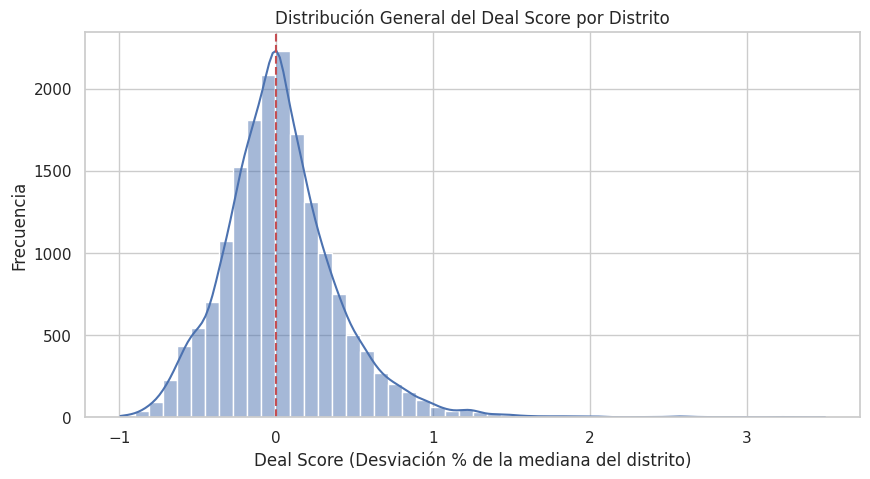

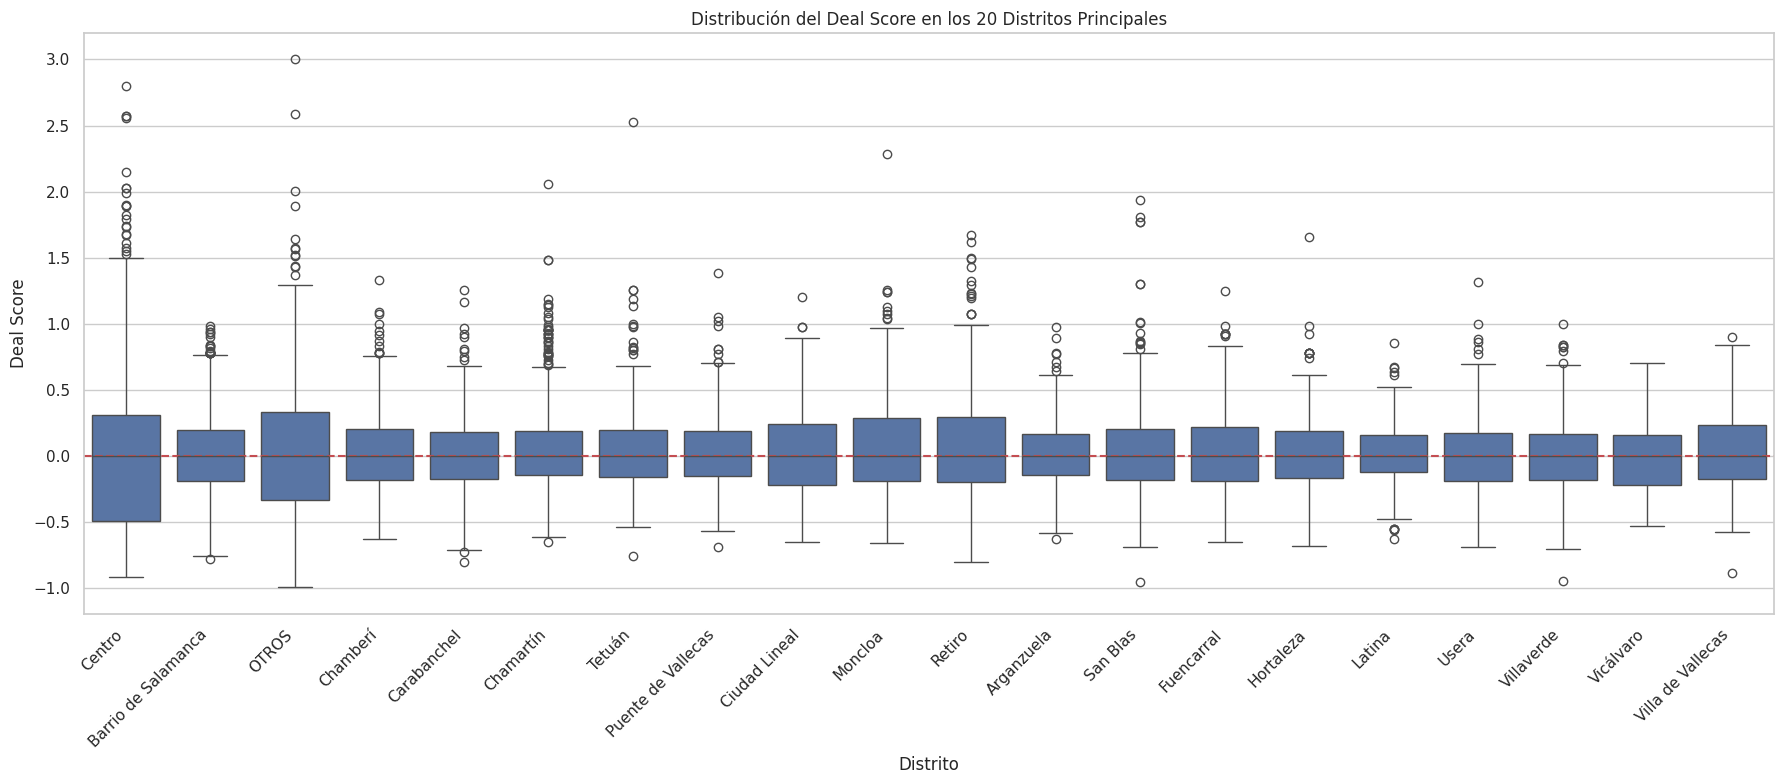

In [18]:
# Histograma de la distribución general ---
plt.figure(figsize=(10, 5))
sns.set(style="whitegrid")
sns.histplot(df_limpios['deal_score_district'], kde=True, bins=50)
plt.axvline(0, color='r', linestyle='--')
plt.title('Distribución General del Deal Score por Distrito')
plt.xlabel('Deal Score (Desviación % de la mediana del distrito)')
plt.ylabel('Frecuencia')
plt.show()


# Boxplot para los 20 distritos principales ---

top_20_districts = df_limpios['district'].value_counts().nlargest(20).index
df_top_districts = df_limpios[df_limpios['district'].isin(top_20_districts)]

plt.figure(figsize=(18, 8))
ax = sns.boxplot(
    x='district',
    y='deal_score_district',
    data=df_top_districts,
    order=top_20_districts
)
ax.axhline(0, color='r', linestyle='--')
plt.title('Distribución del Deal Score en los 20 Distritos Principales')
plt.xlabel('Distrito')
plt.ylabel('Deal Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [19]:
#Visualización de los 15 distritos principales ---

top_15_districts = df_limpios['district'].value_counts().nlargest(15).index

# Mapa base
mapa_distritos = folium.Map(location=[df_limpios['latitude'].mean(), df_limpios['longitude'].mean()], zoom_start=11)

# Paleta de colores y mapa de colores
colors = sns.color_palette('bright', n_colors=len(top_15_districts)).as_hex()
color_map = {district: colors[i] for i, district in enumerate(top_15_districts)}

# Añadir puntos al mapa
sample_size = min(len(df_limpios), 7000)
df_sample = df_limpios.sample(n=sample_size, random_state=42)

for index, row in df_sample.iterrows():
    district = row['district']

    # Asignar color solo si el distrito está en nuestro top 15, si no, gris
    point_color = color_map.get(district, '#808080')

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=3,
        color=point_color,
        fill=True,
        fill_color=point_color,
        fill_opacity=0.7 if district in top_15_districts else 0.2,
        popup=f"Distrito: {district}"
    ).add_to(mapa_distritos)

# 5. Crear y añadir leyenda
legend_html = '''
<div style="position: fixed;
            bottom: 50px; left: 50px; width: 220px; height: auto;
            border:2px solid grey; z-index:9999; font-size:12px;
            background-color:white; opacity: 0.9;
            ">&nbsp;<b>Leyenda: Top 15 Distritos</b><br>
'''

for district, color in color_map.items():
    legend_html += f'&nbsp; <i class="fa fa-circle" style="color:{color}"></i>&nbsp; {district}<br>'

legend_html += f'&nbsp; <i class="fa fa-circle" style="color:#D3D3D3"></i>&nbsp; Otros Distritos<br></div>'

mapa_distritos.get_root().html.add_child(folium.Element(legend_html))


# Mapa
mapa_distritos

Output hidden; open in https://colab.research.google.com to view.

### Conclusión Final: KMeans (k=50) es la Estrategia Ganadora

Tras experimentar y analizar tres métodos de zonificación (KMeans, DBSCAN y por Distritos), hemos llegado a una conclusión clara.

| Característica | KMeans (k=50) | DBSCAN | Por Distrito |
| :--- | :--- | :--- | :--- |
| **Granularidad de Zonas** | ✅ **Excelente**: Crea 50 micro-zonas distintas, homogéneas y de tamaño útil. | ❌ **Pobre**: Genera un "super-cluster" demasiado grande y heterogéneo. | ❌ **Inconsistente**: Zonas muy grandes y diversas mezcladas con otras pequeñas. |
| **Utilidad para `deal_score`** | ✅ **Alta**: Permite calcular un precio de mercado muy local y específico. | ❌ **Baja**: La mayoría de inmuebles se comparan contra la misma mediana. | ⚠️ **Media**: Fiable en distritos homogéneos, pero impreciso en los heterogéneos. |
| **Interpretabilidad** | ⚠️ Media | ✅ Alta (outliers) | ✅ **Alta**: Usa nombres de distritos conocidos por todos. |

Justificación
Para nuestro objetivo de crear una variable deal_score robusta y con alto poder predictivo, la zonificación con KMeans (k=50) es la estrategia claramente superior.

- KMeans (k=50) nos proporcionó 50 micro-zonas homogéneas en precio. Esto nos permite calcular un "precio de mercado local" muy fiable, generando un deal_score preciso que captura las variaciones de precios a nivel de barrio.

- DBSCAN, aunque excelente para detectar la estructura de densidad y los outliers geográficos, creó un "super-cluster" demasiado grande y heterogéneo para ser útil en nuestro análisis de precios.

- La agrupación por Distrito, aunque muy interpretable, demostró ser demasiado inconsistente. Algunos distritos son muy homogéneos mientras que otros son extremadamente diversos, lo que hace que el deal_score sea menos fiable en esas zonas.

Por tanto, procederemos a la fase de modelado utilizando deal_score_k50 como nuestra principal variable objetivo o característica de valor.

## Conclusión de Feature Engineering: Guardado del Dataset Final
Habiendo concluido el análisis comparativo, se procede a preparar el dataset final para el modelado.

Este bloque de código realiza las siguientes acciones:

- Selecciona las columnas definitivas, conservando las características originales, las de feature engineering y, lo más importante, las columnas ganadoras de nuestro análisis: zona_cluster_k50 y deal_score_k50.

- Elimina todas las columnas intermedias usadas en la comparativa (el resto de deal_scores, clusters, etc.).

- Renombra las columnas ganadoras a nombres genéricos (zona_cluster y deal_score) para facilitar su uso en el futuro.

- Guarda el DataFrame resultante en un nuevo archivo CSV (df_limpios_con_vd.csv), que servirá como punto de partida limpio para toda la fase de entrenamiento de modelos.

In [20]:


# Bloque Final: Preparación del Dataset para Modelado ---

# Definir la variable dependiente y la de zonificación ganadoras
target_col = 'deal_score_k50'
zone_col = 'zona_cluster_k50'

df_final_modelado = df_limpios.copy()

# Limpiar el dataframe de todos los otros clusters y deal_scores que generamos
cols_to_drop = [col for col in df_final_modelado.columns if ('_k' in col or '_dbscan' in col or '_district' in col) and col not in [target_col, zone_col]]
df_final_modelado.drop(columns=cols_to_drop, inplace=True)

# Renombrar columnas ganadoras
df_final_modelado.rename(columns={
    target_col: 'deal_score',
    zone_col: 'zona_cluster'
}, inplace=True)

# Guardar DataFrame final
output_filename = 'df_limpios_con_vd.csv'
df_final_modelado.to_csv(output_filename, index=False)

print(f"DataFrame final preparado para el modelado.")
print(f"Dimensiones del DataFrame: {df_final_modelado.shape}")
print(f"Archivo '{output_filename}' guardado con éxito en el entorno de Colab.")
print("\nColumnas finales:")
print(df_final_modelado.columns.tolist())

DataFrame final preparado para el modelado.
Dimensiones del DataFrame: (17456, 39)
Archivo 'df_limpios_con_vd.csv' guardado con éxito en el entorno de Colab.

Columnas finales:
['bathrooms', 'detailedType.subTypology', 'detailedType.typology', 'district', 'exterior', 'floor', 'has360', 'has3DTour', 'hasLift', 'hasPlan', 'hasStaging', 'hasVideo', 'latitude', 'longitude', 'municipality', 'newDevelopment', 'numPhotos', 'parkingSpace.hasParkingSpace', 'parkingSpace.isParkingSpaceIncludedInPrice', 'parkingSpace.parkingSpacePrice', 'price', 'priceByArea', 'priceInfo.price.priceDropInfo.priceDropPercentage', 'priceInfo.price.priceDropInfo.priceDropValue', 'propertyType', 'rooms', 'showAddress', 'size', 'status', 'topPlus', 'floor_cat', 'has_neighborhood', 'has_Discount', 'distancia_al_centro', 'price_per_room', 'size_per_room', 'amenities_score', 'zona_cluster', 'deal_score']


### Interpretación y Relevancia de la Variable deal_score

Tras un análisis comparativo de múltiples técnicas de zonificación, se seleccionó el método de clustering con KMeans (k=50) como la estrategia óptima para definir los mercados inmobiliarios locales. A partir de esta segmentación, se construyó la variable objetivo principal: el deal_score.

**¿Qué representa el deal_score?**

El deal_score es una métrica de valor relativo que cuantifica qué tan buena o mala es la oferta de un inmueble en comparación con su entorno geográfico inmediato. Se calcula como la desviación porcentual del precio por metro cuadrado (priceByArea) de un inmueble con respecto al precio mediano de la zona a la que pertenece.

- Un deal_score negativo (ej. -0.25) indica una oportunidad o buena oferta, ya que el inmueble es un 25% más barato que el precio típico de su micro-mercado.

- Un deal_score positivo (ej. +0.30) indica un posible sobreprecio, ya que el inmueble es un 30% más caro que la mediana de su zona.

- Un deal_score cercano a cero indica que el inmueble está valorado en línea con su mercado local.

La principal fortaleza de esta variable es que contextualiza el precio. En lugar de simplemente saber que un piso cuesta 500,000€, el deal_score nos dice si esos 500,000€ son una ganga o una exageración para esa calle y ese barrio en concreto.

**Relevancia para el Modelo Predictivo**

Esta variable es fundamental para el éxito del modelo por varias razones:

- Alto Poder Predictivo: Condensa información compleja (geografía y precios) en un único y potente predictor.

- Identificación de Oportunidades: Permite al modelo aprender qué características (nº de baños, estado de conservación, etc.) están asociadas con las buenas y malas ofertas.

- Versatilidad: Puede ser utilizada tanto como una variable predictora (para predecir el precio final) como una variable objetivo (si el objetivo del modelo fuera predecir la "calidad de la oferta").

/tmp/ipython-input-4144606297.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(y=df_limpios['deal_score_k50'], palette=['#A2C2F0'])


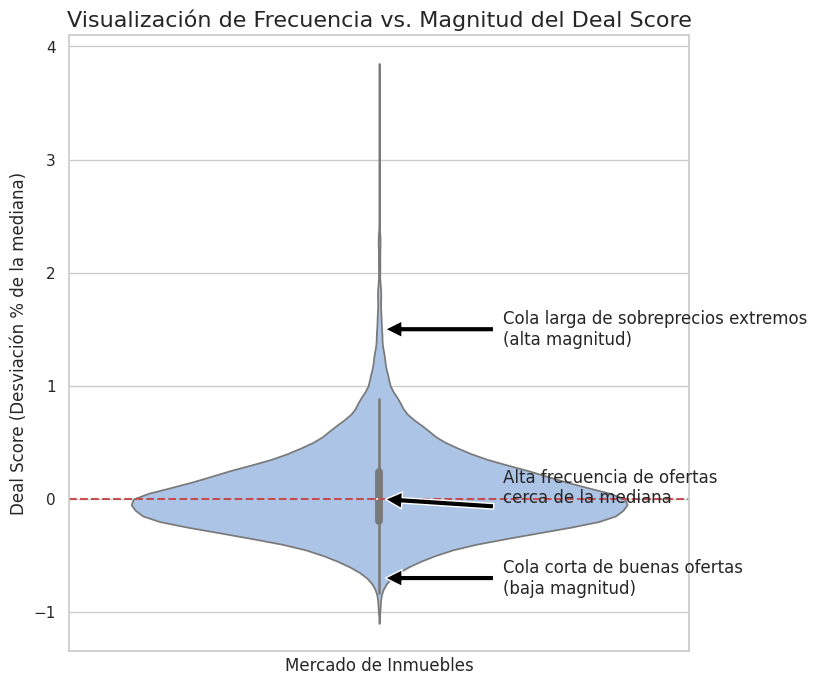

In [21]:
#Gráfico de Violín para Frecuencia vs. Magnitud ---

plt.figure(figsize=(8, 8))
sns.set(style="whitegrid")

# Crear el diagrama
ax = sns.violinplot(y=df_limpios['deal_score_k50'], palette=['#A2C2F0'])

# Línea de referencia en la mediana (cero)
ax.axhline(0, color='r', linestyle='--')

# Anotaciones
plt.annotate('Alta frecuencia de ofertas\ncerca de la mediana',
             xy=(0, 0), xytext=(0.2, 0.1),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='center')

plt.annotate('Cola larga de sobreprecios extremos\n(alta magnitud)',
             xy=(0, 1.5), xytext=(0.2, 1.5),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='center')

plt.annotate('Cola corta de buenas ofertas\n(baja magnitud)',
             xy=(0, -0.7), xytext=(0.2, -0.7),
             arrowprops=dict(facecolor='black', shrink=0.05),
             ha='left', va='center')


# Títulos y etiquetas
plt.title('Visualización de Frecuencia vs. Magnitud del Deal Score', fontsize=16)
plt.ylabel('Deal Score (Desviación % de la mediana)')
plt.xlabel('Mercado de Inmuebles')
plt.xticks([])

plt.show()

A primera vista, un reparto casi perfecto del 50% entre ofertas por encima y por debajo de la mediana podría parecer contraintuitivo en un mercado que se percibe con tendencia al sobreprecio. Sin embargo, este resultado es matemáticamente correcto y valida la robustez de nuestro deal_score.

La clave para entenderlo es diferenciar entre la frecuencia de las ofertas (el conteo de inmuebles) y la magnitud de las mismas (el valor del deal_score).

- **La Frecuencia es Simétrica por Diseño:** Nuestro deal_score se calcula usando la mediana como punto de referencia. La mediana es, por definición, el valor que divide un conjunto de datos en dos mitades iguales. Por lo tanto, es matemáticamente inevitable que aproximadamente el 50% de los inmuebles estén por encima y el 50% por debajo. Obtener este resultado confirma que el cálculo es correcto.

- **La Magnitud es Asimétrica y Refleja el Mercado:** La tendencia real del mercado al sobreprecio no se ve en el número de inmuebles caros, sino en lo caros que llegan a ser. Como observamos en el histograma del deal_score, la distribución es asimétrica: la "cola" de la derecha (sobreprecios) es mucho más larga y extendida que la de la izquierda.

In [22]:
# Mapa de Calor del Deal Score

# Mapa base
mapa_deal_score_final = folium.Map(location=[df_limpios['latitude'].mean(), df_limpios['longitude'].mean()], zoom_start=11)

# 2. Escala de colores Verde-Amarillo-Rojo
min_score = -0.50
max_score = 0.50

colormap = LinearColormap(
    colors=['green', 'yellow', 'red'],
    index=[min_score, 0, max_score],
    vmin=min_score,
    vmax=max_score
)
colormap.caption = 'Deal Score (Verde = Buena Oferta, Rojo = Sobreprecio)'

# Añadir los puntos al mapa
sample_size = min(len(df_limpios), 5000)
df_sample = df_limpios.sample(n=sample_size, random_state=42)

for index, row in df_sample.iterrows():
    score = row['deal_score_k50']
    score_clamped = max(min_score, min(score, max_score))

    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=4,
        color=colormap(score_clamped),
        fill=True,
        fill_color=colormap(score_clamped),
        fill_opacity=0.7,
        popup=f"Deal Score: {score:.2%}<br>Precio/m²: {row['priceByArea']:,.0f} €"
    ).add_to(mapa_deal_score_final)

mapa_deal_score_final.add_child(colormap)

# Mapa
mapa_deal_score_final

Output hidden; open in https://colab.research.google.com to view.

### Prueba utilidad clustering

In [23]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error

# --- Prueba de Aporte de Valor del Clustering ---

# --- Modelo 1: SIN la información del cluster ---
features_sin_cluster = numeric_features + categorical_features
features_sin_cluster.remove('zona_cluster') # Quitamos la columna del cluster

preprocessor_sin_cluster = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), [f for f in numeric_features if f != 'zona_cluster']),
        ('cat', OneHotEncoder(handle_unknown='ignore'), [f for f in categorical_features if f != 'zona_cluster'])
    ])

X_train_sin_cluster = preprocessor_sin_cluster.fit_transform(X_train[features_sin_cluster])
X_test_sin_cluster = preprocessor_sin_cluster.transform(X_test[features_sin_cluster])

model_sin_cluster = Ridge()
model_sin_cluster.fit(X_train_sin_cluster, y_train)
pred_sin_cluster = model_sin_cluster.predict(X_test_sin_cluster)
mae_sin_cluster = mean_absolute_error(y_test, pred_sin_cluster)

print(f"Rendimiento del Modelo SIN Cluster: MAE = {mae_sin_cluster:.4f}")


# --- Modelo 2: CON la información del cluster ---
# Reutilizamos los datos que ya teníamos preprocesados para la ANN ('X_train_ohe')
model_con_cluster = Ridge()
model_con_cluster.fit(X_train_ohe, y_train)
pred_con_cluster = model_con_cluster.predict(X_test_ohe)
mae_con_cluster = mean_absolute_error(y_test, pred_con_cluster)

print(f"Rendimiento del Modelo CON Cluster: MAE = {mae_con_cluster:.4f}")

# --- Conclusión ---
mejora_porcentual = ((mae_sin_cluster - mae_con_cluster) / mae_sin_cluster) * 100
print(f"\nConclusión: Añadir la 'zona_cluster' ha mejorado el modelo en un {mejora_porcentual:.2f}%.")

NameError: name 'numeric_features' is not defined